 TASK 1: Import and Preprocess the Dataset

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


# Load the dataset
df = pd.read_csv('C:/Users/Administrator/Documents/Dhruvil/Projects/Data Science/Data Science xl files/fifa_world_cup_2026_player_performance.csv')

# Select feature (X) and target (y) columns
cols_to_use = ["minutes_played", "distance_covered_km"]

# Drop rows where either minutes_played or distance_covered_km is missing (NaN)
df_clean = df[cols_to_use].dropna()

# Define X (2D DataFrame) and y (1D Series)
X = df_clean[["minutes_played"]]
y = df_clean["distance_covered_km"]

print(df)

   player_id          player_name   age    nationality          team  \
0     P00055           Rodri Fati  26.0        Spanish         Spain   
1     P00070      Ansu Le Normand  19.0        Spanish         Spain   
2     P00066           Gavi Ramos  18.0        Spanish         Spain   
3     P00073        Pedro Cubarsi  20.0        Spanish         Spain   
4     P00059     Alvaro Oyarzabal  23.0        Spanish         Spain   
5     P00072            Dani Gavi  21.0        Spanish         Spain   
6     P00058        Rodri Laporte  27.0        Spanish         Spain   
7     P00078            Ansu Fati  27.0            NaN         Spain   
8     P00056         Pedro Torres  24.0        Spanish         Spain   
9     P00074                  NaN  25.0        Spanish         Spain   
10    P00069       Ferran Cubarsi  24.0        Spanish         Spain   
11    P00071          Marco Mikel  18.0        Spanish           NaN   
12    P00076          Alvaro Gavi  28.0            NaN         S

TASK 2: Split the dataset into Train-Test sets

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

TASK 3: Fit a Linear Regression model

In [11]:
# Initialize and train the Ordinary Least Squares Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

TASK 4: Evaluate Model using MAE, MSE, R²

In [12]:
# Generate predictions on the unseen test dataset
y_pred = model.predict(X_test)

# Calculate error and variance metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- MODEL EVALUATION METRICS ---")
print(f"Mean Absolute Error (MAE): {mae:.4f} km")
print(f"Mean Squared Error (MSE):  {mse:.4f}")
print(f"R² Score (Coefficient of Determination): {r2:.4f}")
print("-" * 32)
print(f"Regression Slope (Coefficient): {model.coef_[0]:.4f}")
print(f"Regression Intercept:           {model.intercept_:.4f}")

--- MODEL EVALUATION METRICS ---
Mean Absolute Error (MAE): 0.7201 km
Mean Squared Error (MSE):  0.7704
R² Score (Coefficient of Determination): 0.9469
--------------------------------
Regression Slope (Coefficient): 0.1103
Regression Intercept:           -0.0362


TASK 5: Plot Regression Line & Visuals

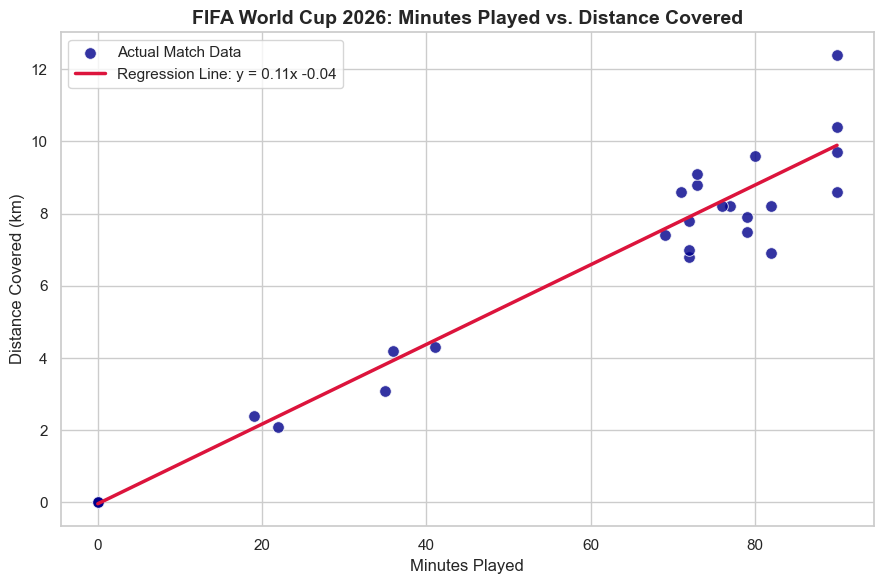

In [14]:
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

# Scatter plot of actual data points
sns.scatterplot(
    x=df_clean["minutes_played"],
    y=df_clean["distance_covered_km"],
    color="darkblue",
    s=70,
    label="Actual Match Data",
    alpha=0.8,
)

# Generate a continuous line across the full range of X values
x_range = pd.DataFrame(
    np.linspace(
        df_clean["minutes_played"].min(),
        df_clean["minutes_played"].max(),
        100,
    ),
    columns=["minutes_played"],
)

y_range_pred = model.predict(x_range)

# Plot the regression line
plt.plot(
    x_range["minutes_played"],
    y_range_pred,
    color="crimson",
    linewidth=2.5,
    label=f"Regression Line: y = {model.coef_[0]:.2f}x {model.intercept_:+.2f}",
)

# Formatting labels and titles
plt.title(
    "FIFA World Cup 2026: Minutes Played vs. Distance Covered",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Minutes Played", fontsize=12)
plt.ylabel("Distance Covered (km)", fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()

# Display the plot
plt.show()